# 05 - Collision Hotspots with k-Means Clustering

**This uses Module 5 of our course: unsupervised learning.**

Everything so far was supervised learning - we had labels (the severity) and
we trained a model to predict them.

Clustering is different. There are no labels. We just give the algorithm the
collision locations and it finds groups on its own.

**What we build here:** collision hotspot zones for the map.

We take the latitude and longitude of every collision and cluster them.
Each cluster is a danger zone. The app draws these on the map as coloured areas.

Our syllabus lists anomaly detection and segmentation as clustering uses.
Finding geographic danger zones is the same idea applied to road safety.


(22990, 19)


C:\Users\PCWORLD\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\PCWORLD\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\PCWORLD\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PCWORLD\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", l

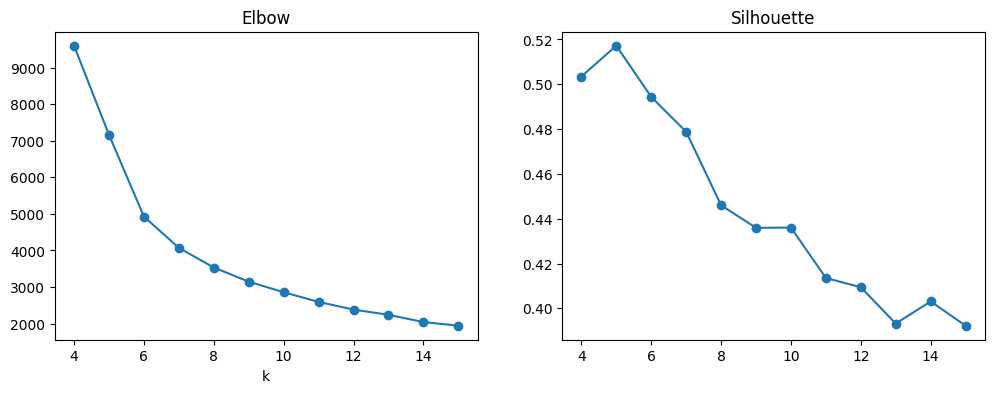

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parents[1] / "ml" / "src"))
from config import CLEAN_FILE, ARTIFACTS_DIR, PROCESSED_DIR

df = pd.read_parquet(CLEAN_FILE)

# Focus on one region for demo (Manchester–Sheffield corridor example)
mask = (
    (df["latitude"].between(53.2, 53.6)) &
    (df["longitude"].between(-2.5, -1.3))
)
df_region = df[mask].copy()
print(df_region.shape)

coords = df_region[["latitude", "longitude"]].values
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

# Elbow + Silhouette
inertias = []
silhouettes = []
K_range = range(4, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(coords_scaled, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, "o-")
plt.title("Elbow")
plt.xlabel("k")
plt.subplot(1,2,2)
plt.plot(K_range, silhouettes, "o-")
plt.title("Silhouette")
plt.show()

In [2]:
K = 8   # chosen from the elbow and silhouette plots above
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_region["cluster"] = kmeans.fit_predict(coords_scaled)

# Per-cluster stats. The mean lat/lon of a cluster is its k-Means centre.
cluster_stats = (
    df_region.groupby("cluster")
    .agg(
        total_collisions=("collision_severity", "size"),
        fatal=("collision_severity", lambda x: (x==1).sum()),
        serious=("collision_severity", lambda x: (x==2).sum()),
        centre_lat=("latitude", "mean"),
        centre_lon=("longitude", "mean"),
    )
    .reset_index()
)
cluster_stats["severe_rate"] = (
    (cluster_stats["fatal"] + cluster_stats["serious"]) / cluster_stats["total_collisions"]
)

# Radius for the map circle: the distance that covers 3 in 4 of the zone's collisions
radii = []
for cluster, centre_lat, centre_lon in cluster_stats[["cluster", "centre_lat", "centre_lon"]].itertuples(index=False):
    points = df_region[df_region["cluster"] == cluster]
    lat1, lon1 = np.radians(centre_lat), np.radians(centre_lon)
    lat2, lon2 = np.radians(points["latitude"]), np.radians(points["longitude"])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    distances_km = 2 * 6371 * np.arcsin(np.sqrt(a))
    radii.append(np.percentile(distances_km, 75))
cluster_stats["radius_km"] = radii

# Thirds of the observed severe rates, so low, moderate and high are all used
cluster_stats["risk_band"] = pd.qcut(
    cluster_stats["severe_rate"], 3, labels=["low", "moderate", "high"]
).astype(str)
print(cluster_stats.round(3))

# Save
joblib.dump(
    {"kmeans": kmeans, "scaler": scaler, "k": K},
    ARTIFACTS_DIR / "hotspot_kmeans.joblib"
)
cluster_stats.to_parquet(PROCESSED_DIR / "hotspot_clusters.parquet", index=False)

   cluster  total_collisions  fatal  serious  centre_lat  centre_lon  \
0        0              2173     39      758      53.547      -1.487   
1        1              2623     47      715      53.393      -2.227   
2        2              5732    101     1591      53.472      -2.214   
3        3              1350     20      328      53.248      -1.460   
4        4              3011     47      957      53.365      -1.463   
5        5              4101     76     1137      53.554      -2.286   
6        6              1505     30      326      53.276      -2.184   
7        7              2495     38      716      53.432      -1.416   

   severe_rate  radius_km risk_band  
0        0.367     10.997      high  
1        0.291      8.194       low  
2        0.295      8.281  moderate  
3        0.258      8.674       low  
4        0.333      5.311      high  
5        0.296     10.932  moderate  
6        0.237     17.934       low  
7        0.302      6.128      high  



### Choice of k
We examined the elbow curve and silhouette scores for k = 4 to 15. We selected **k = 8** because:
- it sits near the elbow,
- silhouette score was competitive,
- eight zones remain readable on a city-scale map.

Three zones are too coarse; fifty zones become visual noise.

### What we store per cluster
- Total collisions  
- Fatal and Serious counts  
- Severe rate (Fatal + Serious) / Total  
- Cluster centre (lat, lon)  
- Radius in km: the distance covering 3 in 4 of the zone's collisions, used to draw the circle  
- Risk band: low / moderate / high, split into thirds of the observed severe rates so every band is used

### Why k-Means and not DBSCAN?
k-Means is the algorithm taught in the module and produces stable, roughly balanced zones that are easy to colour on a map.  
DBSCAN would follow long thin road shapes better, but needs careful density-parameter tuning and can produce many tiny or noise clusters. For zone-level visualisation k-Means is adequate; we state this limitation honestly.

### Artifacts
- `hotspot_kmeans.joblib` — fitted k-Means + scaler (so the backend can transform a live point the same way)  
- `hotspot_clusters.parquet` — per-cluster statistics for the map and Insights page